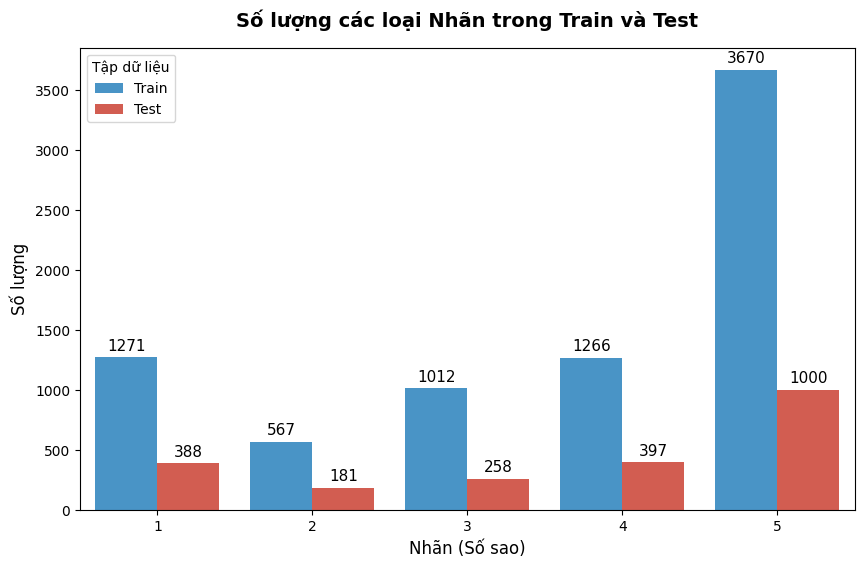

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc file thẳng
train_df = pd.read_csv('../dataset/train.csv')
test_df = pd.read_csv('../dataset/test.csv')

# Lấy cột label và đếm số lượng
train_counts = train_df['label'].value_counts().reset_index()
train_counts.columns = ['Nhãn', 'Số lượng']
train_counts['Tập'] = 'Train'

test_counts = test_df['label'].value_counts().reset_index()
test_counts.columns = ['Nhãn', 'Số lượng']
test_counts['Tập'] = 'Test'

# Gộp chung vào 1 bảng
combined = pd.concat([train_counts, test_counts])

# Thiết lập kích thước và vẽ biểu đồ
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=combined, x='Nhãn', y='Số lượng', hue='Tập', palette=['#3498db', '#e74c3c'])

# ĐÂY LÀ PHẦN GẮN SỐ LÊN CỘT
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=11)

plt.title('Số lượng các loại Nhãn trong Train và Test', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nhãn (Số sao)', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)
plt.legend(title='Tập dữ liệu')
plt.show()


=== THỐNG KÊ CHI TIẾT VĂN BẢN (TRAIN + TEST) ===
Tổng số bình luận phân tích : 10,010 câu
Độ dài lớn nhất (Max length) : 205 từ
Độ dài nhỏ nhất (Min length) : 2 từ
Độ dài trung bình (Avg length): 36.31 từ
Kích thước từ vựng (Vocab)   : 20,294 từ duy nhất


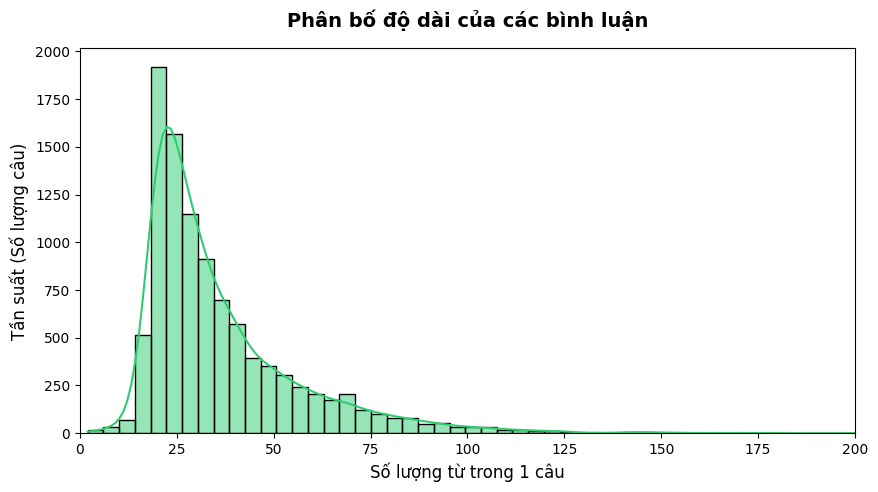

In [2]:
# Xác định tên cột chứa văn bản (comment hoặc comments)
text_col = "comments" if "comments" in train_df.columns else "comment"

# Gom chung văn bản của Train và Test, loại bỏ các dòng rỗng
all_texts = pd.concat([train_df[text_col], test_df[text_col]]).dropna().astype(str)

# Tính độ dài của từng câu (dựa trên số lượng từ, cách nhau bởi khoảng trắng)
sentence_lengths = all_texts.apply(lambda x: len(x.split()))

# Tính toán các chỉ số cơ bản
max_len = sentence_lengths.max()
min_len = sentence_lengths.min()
avg_len = sentence_lengths.mean()

# Tính kích thước từ vựng (Vocabulary size)
# Gom tất cả các từ trong toàn bộ dataset lại thành 1 chuỗi khổng lồ, sau đó tách ra và bỏ vào Set để đếm
all_words = " ".join(all_texts.tolist()).split()
vocab_size = len(set(all_words))

# In kết quả
print("=== THỐNG KÊ CHI TIẾT VĂN BẢN (TRAIN + TEST) ===")
print(f"Tổng số bình luận phân tích : {len(all_texts):,} câu")
print(f"Độ dài lớn nhất (Max length) : {max_len} từ")
print(f"Độ dài nhỏ nhất (Min length) : {min_len} từ")
print(f"Độ dài trung bình (Avg length): {avg_len:.2f} từ")
print(f"Kích thước từ vựng (Vocab)   : {vocab_size:,} từ duy nhất")

# Vẽ thêm biểu đồ phân bố độ dài câu (Tặng thêm)
plt.figure(figsize=(10, 5))
sns.histplot(sentence_lengths, bins=50, kde=True, color='#2ecc71')
plt.title('Phân bố độ dài của các bình luận', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Số lượng từ trong 1 câu', fontsize=12)
plt.ylabel('Tần suất (Số lượng câu)', fontsize=12)
plt.xlim(0, max_len if max_len < 200 else 200) # Cắt trục X ở 200 để tránh các câu nhiễu quá dài làm xấu biểu đồ
plt.show()


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

LABEL_NAMES = ["Tiêu cực", "Trung tính", "Tích cực"]

def plot_cm(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=LABEL_NAMES)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100  # Tỷ lệ %

    # Tạo annotation: "số\n(tỷ lệ%)"
    annot = [[f"{cm[i][j]}\n({cm_pct[i][j]:.1f}%)" for j in range(3)] for i in range(3)]

    sns.heatmap(
        cm_pct, ax=ax,
        annot=annot, fmt="", cmap="Blues",
        xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
        linewidths=0.5, linecolor="gray",
        vmin=0, vmax=100,
        cbar_kws={"format": "%.0f%%"}
    )
    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel("Nhãn Dự Đoán", fontsize=11)
    ax.set_ylabel("Nhãn Thực Tế", fontsize=11)

# ============================================================


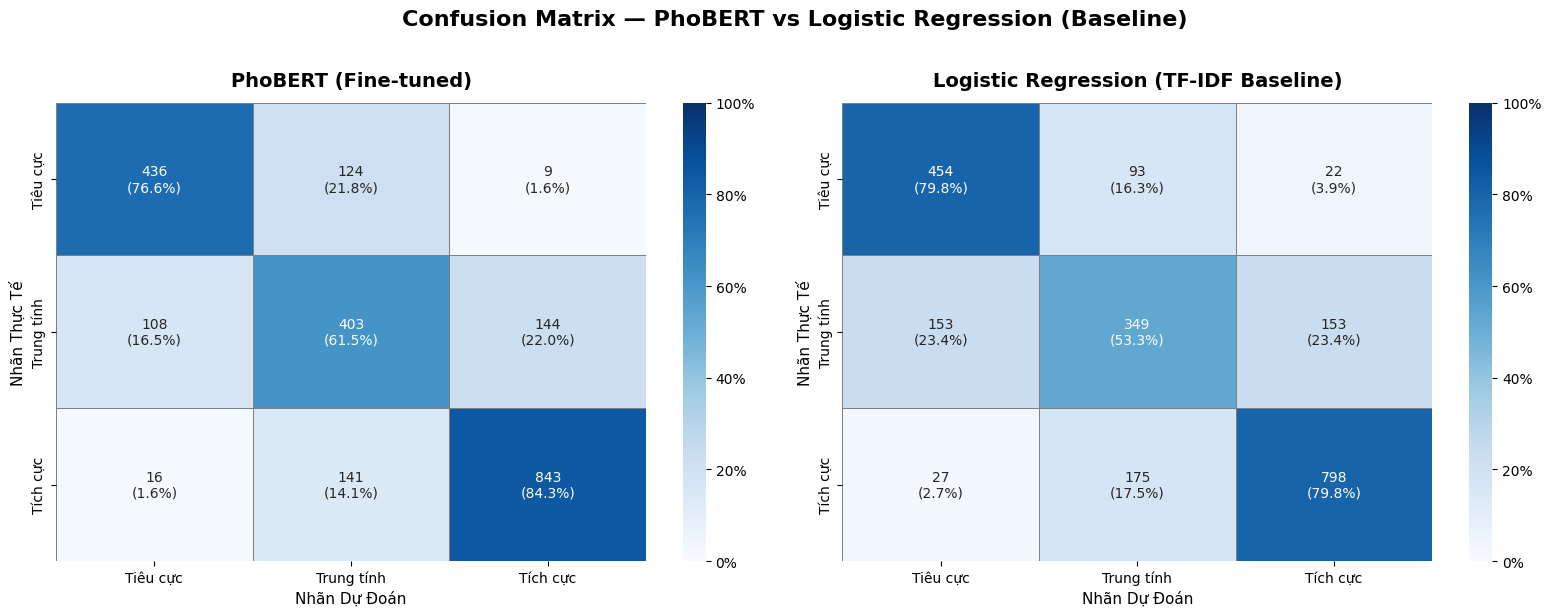

[INFO] Đã lưu ảnh → confusion_matrix_comparison.png


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

LABEL_NAMES = ["Tiêu cực", "Trung tính", "Tích cực"]

def plot_cm(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=LABEL_NAMES)
    # Tính tỷ lệ % theo hàng (theo nhãn thực tế)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot = [[f"{cm[i][j]}\n({cm_pct[i][j]:.1f}%)" for j in range(3)] for i in range(3)]

    sns.heatmap(
        cm_pct, ax=ax,
        annot=annot, fmt="", cmap="Blues",
        xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
        linewidths=0.5, linecolor="gray",
        vmin=0, vmax=100,
        cbar_kws={"format": "%.0f%%"}
    )
    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel("Nhãn Dự Đoán", fontsize=11)
    ax.set_ylabel("Nhãn Thực Tế", fontsize=11)

# --- Đọc file kết quả đã lưu sẵn ---
phobert_df  = pd.read_csv("../test_predictions.csv")
baseline_df = pd.read_csv("../baseline_logistic_predictions.csv")

# --- Vẽ 2 confusion matrix song song ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Confusion Matrix — PhoBERT vs Logistic Regression (Baseline)",
             fontsize=16, fontweight="bold", y=1.02)

plot_cm(axes[0],
        phobert_df["Nhãn thực tế"],
        phobert_df["Nhãn dự đoán"],
        "PhoBERT (Fine-tuned)")

plot_cm(axes[1],
        baseline_df["Nhãn thực tế"],
        baseline_df["Nhãn dự đoán (Logistic)"],
        "Logistic Regression (TF-IDF Baseline)")

plt.tight_layout()
plt.savefig("confusion_matrix_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("[INFO] Đã lưu ảnh → confusion_matrix_comparison.png")
